/var/folders/88/w4w1n8l12kd_z42_6mrnndmw0000gn/T/ipykernel_4513/1316066826.py:13: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  text_cols = df.select_dtypes(include="object").columns


                                                text  Cluster
0  Abbeyhill Primary School Nursery Class Abbey S...        2
1  Arbor Green Nursery 22 Arboretum Avenue EH4 1H...        1
2  Balgreen Nursery School 175 Balgreen Road EH11...        1
3  Barnton Nursery 534 Queensferry Road EH4 6EE 0...        1
4  Blackhall Nursery Ravelston Park Pavilion, Cra...        1
5  Blossom Tree Nursery 2 Newtoft Street EH17 8RE...        1
6  Bonaly Primary School Nursery Class 57 Bonaly ...        2
7  Bonnington House Nursery 159 Newhaven Road EH6...        1
8  Bright Horizons Family Solutions - Annandale A...        1
9  Bright Horizons Family Solutions - Bruntsfield...        1

Cluster counts:
Cluster
1    128
2     70
0     14
Name: count, dtype: int64


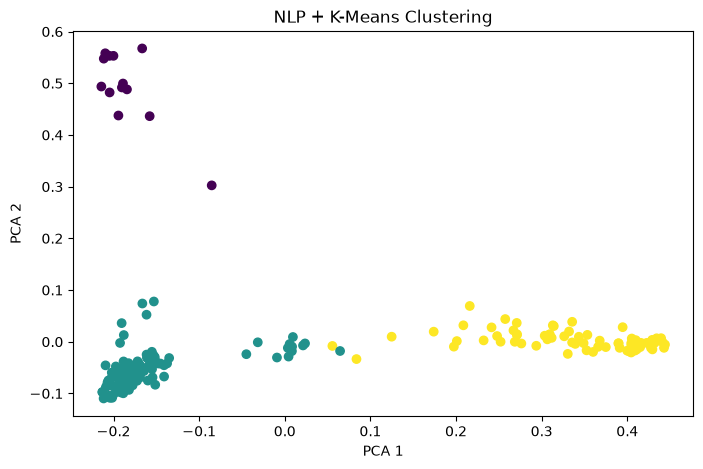

In [1]:
# NLP + K-Means for Nursery and Early Years

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# 1. Load dataset
df = pd.read_csv("Nursery and early years.csv")

# 2. Select text columns
text_cols = df.select_dtypes(include="object").columns
df["text"] = df[text_cols].fillna("").astype(str).agg(" ".join, axis=1)

# 3. NLP - TF-IDF
tfidf = TfidfVectorizer(stop_words="english", max_features=2000)
X = tfidf.fit_transform(df["text"])

# 4. K-Means
k = 3
model = KMeans(n_clusters=k, random_state=42, n_init=10)
df["Cluster"] = model.fit_predict(X)

# 5. Show results
print(df[["text", "Cluster"]].head(10))
print("\nCluster counts:")
print(df["Cluster"].value_counts())

# 6. PCA for visualisation
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X.toarray())

plt.figure(figsize=(8,5))
plt.scatter(X_pca[:,0], X_pca[:,1], c=df["Cluster"])
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.title("NLP + K-Means Clustering")
plt.show()

# 7. Save results
df.to_csv("Nursery_KMeans_results.csv", index=False)